In [1]:
import re

## Regex

In [2]:
# Função auxiliar para destacar o resultado do RegEX

def mostrar_match(padrao, texto, descricao):
    print(f'--- {descricao} ---')
    print(f'Padrão: {padrao} | Texto: "{texto}"')
    encontrados = re.findall(padrao,texto)
    print(f'Resultados: {encontrados}\n')

### Metacaracteres, Classes Personalizadas e Quantificadores

In [3]:
texto_exemplo = "O agente 007 ligou às 14h. O código informado foi o aeiou_123"
mostrar_match(r'\d',texto_exemplo, "Dígitos individuais (\\d)")

--- Dígitos individuais (\d) ---
Padrão: \d | Texto: "O agente 007 ligou às 14h. O código informado foi o aeiou_123"
Resultados: ['0', '0', '7', '1', '4', '1', '2', '3']



In [4]:
mostrar_match(r'\w',texto_exemplo, "Alfanuméricos individuais (\\w)")

--- Alfanuméricos individuais (\w) ---
Padrão: \w | Texto: "O agente 007 ligou às 14h. O código informado foi o aeiou_123"
Resultados: ['O', 'a', 'g', 'e', 'n', 't', 'e', '0', '0', '7', 'l', 'i', 'g', 'o', 'u', 'à', 's', '1', '4', 'h', 'O', 'c', 'ó', 'd', 'i', 'g', 'o', 'i', 'n', 'f', 'o', 'r', 'm', 'a', 'd', 'o', 'f', 'o', 'i', 'o', 'a', 'e', 'i', 'o', 'u', '_', '1', '2', '3']



In [5]:
mostrar_match(r'\s',texto_exemplo, "Espaços em branco (\\s)")

--- Espaços em branco (\s) ---
Padrão: \s | Texto: "O agente 007 ligou às 14h. O código informado foi o aeiou_123"
Resultados: [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']



In [6]:
mostrar_match(r'agente ...', texto_exemplo, "Ponto (.) pegando 007")

--- Ponto (.) pegando 007 ---
Padrão: agente ... | Texto: "O agente 007 ligou às 14h. O código informado foi o aeiou_123"
Resultados: ['agente 007']



In [7]:
mostrar_match(r'[aeiou]',texto_exemplo, "Apenas vogais [aeiou]")

--- Apenas vogais [aeiou] ---
Padrão: [aeiou] | Texto: "O agente 007 ligou às 14h. O código informado foi o aeiou_123"
Resultados: ['a', 'e', 'e', 'i', 'o', 'u', 'i', 'o', 'i', 'o', 'a', 'o', 'o', 'i', 'o', 'a', 'e', 'i', 'o', 'u']



In [8]:
texto_quant = "a aa aaab ab b"

mostrar_match(r'a+',texto_quant, "Um ou mais 'a' (a+)")

--- Um ou mais 'a' (a+) ---
Padrão: a+ | Texto: "a aa aaab ab b"
Resultados: ['a', 'aa', 'aaa', 'a']



In [9]:
mostrar_match(r'a*b',texto_quant, "zero ou mais 'a' seguido de 'b (a*b)")

--- zero ou mais 'a' seguido de 'b (a*b) ---
Padrão: a*b | Texto: "a aa aaab ab b"
Resultados: ['aaab', 'ab', 'b']



In [10]:
mostrar_match(r'a?b',texto_quant, "zero ou 1 'a' seguido de b (a?b)")

--- zero ou 1 'a' seguido de b (a?b) ---
Padrão: a?b | Texto: "a aa aaab ab b"
Resultados: ['ab', 'ab', 'b']



### Âncoras e Fronteiras de Palavras

In [11]:
cpfs = ["12345678900","12345678abc", "cpf: 12345678900"]

In [12]:
# Validação estrita com ^ e $
regex_cpf_estrito = r'^\d{11}$'

for cpf in cpfs:
    match = re.match(regex_cpf_estrito,cpf)
    status = "CPF Válido" if match else "CPF Inválido"
    print(f'CPF: {cpf} - {status}')

CPF: 12345678900 - CPF Válido
CPF: 12345678abc - CPF Inválido
CPF: cpf: 12345678900 - CPF Inválido


In [13]:
texto_fronteira = "A história da inteligência artificial (ia) na Áustria."

mostrar_match(r'ia', texto_fronteira, "Sem Fronteira (pega partes de palavras)")

--- Sem Fronteira (pega partes de palavras) ---
Padrão: ia | Texto: "A história da inteligência artificial (ia) na Áustria."
Resultados: ['ia', 'ia', 'ia', 'ia', 'ia']



In [14]:
mostrar_match(r'\bia\b', texto_fronteira, "Com Fronteira \b (palavra exata)")

--- Com Fronteira (palavra exata) ---
Padrão: \bia\b | Texto: "A história da inteligência artificial (ia) na Áustria."
Resultados: ['ia']



### Grupos de Captura e Backreferences

In [15]:
data_texto = "Data do evento : 10/01/2026"
padrao_data = r'(\d{2})/(\d{2})/(\d{4})'

In [16]:
match = re.search(padrao_data,data_texto)

if match:
    print(f'Texto completo {match.group(0)}')
    print(f'Dia {match.group(1)}')
    print(f'Mês {match.group(2)}')
    print(f'Ano {match.group(3)}')

Texto completo 10/01/2026
Dia 10
Mês 01
Ano 2026


In [17]:
texto_repetido = "Eu eu vi o o e e e pássaro"

padrao_repeticao = r'\b(\w+)\s+\1\b'


In [18]:
repeticoes = re.findall(padrao_repeticao,texto_repetido, flags=re.IGNORECASE)
print(f'Palavras repetidas: {repeticoes}')


Palavras repetidas: ['Eu', 'o', 'e']


### Assertions (Lookahead e Lookbehind)

In [19]:
texto_precos = "O produto A custa R$ 10,00 e o produto AB custa R$ 20,00"

In [20]:
padrao_lookbehind = r'(?<=R\$\s)\d+,\d{2}'

precos = re.findall(padrao_lookbehind,texto_precos)
print(precos)


['10,00', '20,00']


In [21]:
# Extrair a palavra produto, apenas se for seguida por A
padrao_lookahead = r'produto(?=\sA)'

match_ahead = re.findall(padrao_lookahead,texto_precos)
print(match_ahead)

['produto', 'produto']


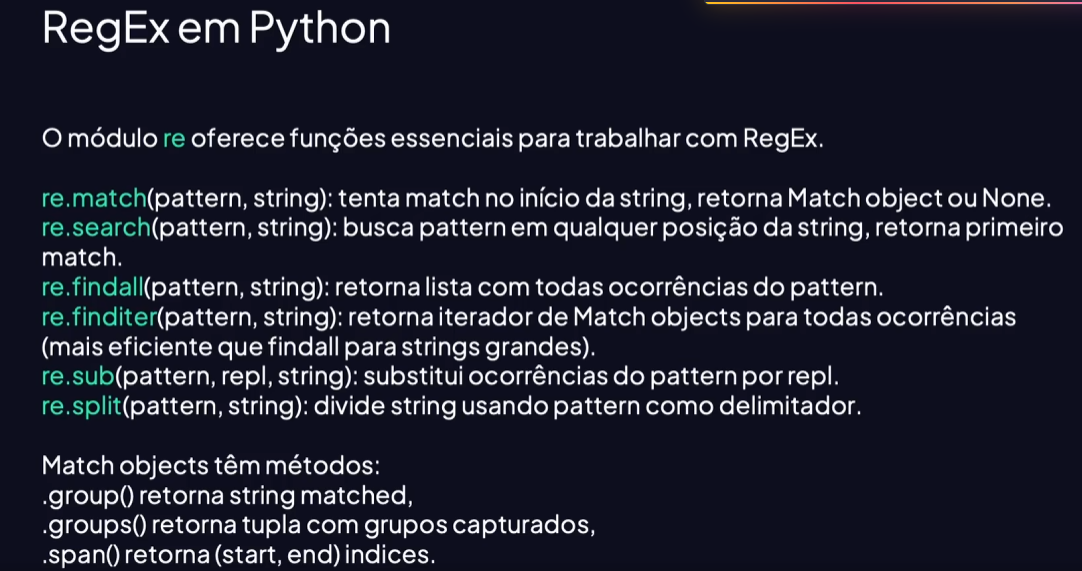

## Recap funções do modulo re

In [22]:
text_lab = "Erro 404: Arquivo não encontrado. Erro 500: Servidor Interno."

In [23]:
# Match vs Search
print(re.match(r'Arquivo', text_lab)) # Retorna no começo da string
print(re.search(r'Arquivo',text_lab)) # Retorna em qualquer parete da string

None
<re.Match object; span=(10, 17), match='Arquivo'>


In [24]:
# Findall vc Finditer
lista_erros = re.findall(r"Erro \d+", text_lab)
print(lista_erros)

['Erro 404', 'Erro 500']


In [25]:
lista_erros_iter = re.finditer(r"Erro \d+", text_lab)
print(lista_erros_iter)

In [26]:
for match_obj in re.finditer(r"Erro (\d+)", text_lab):
    print(match_obj.group())
    print(match_obj.groups()[0])
    print(match_obj.span())

Erro 404
404
(0, 8)
Erro 500
500
(34, 42)


In [27]:
novo_texto = re.sub(r'\d{3}', 'XXX', text_lab)
print(novo_texto)

Erro XXX: Arquivo não encontrado. Erro XXX: Servidor Interno.


In [28]:
partes = re.split(r':\s',text_lab)
print(partes)

['Erro 404', 'Arquivo não encontrado. Erro 500', 'Servidor Interno.']


## Frequência de Palavras

In [44]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# Cada frase está em um documento
corpus_tech = [
    "A ciência de dados utiliza estatística e programação.",
    "A estatística é fundamental para a ciência de dados.",
    "Programação e estatística criam modelos de dados robustos.",
    "O cientista de dados precisa estudar muito."
]

stop_words_pt = nltk.corpus.stopwords.words('portuguese')

In [33]:
vec_freq = CountVectorizer(stop_words=list(stop_words_pt))
X_freq = vec_freq.fit_transform(corpus_tech)

In [35]:
# Somar as contagens de cada palavra
sum_words = X_freq.sum(axis=0)
words_freq = [(word, sum_words[0, idx] )for word, idx in vec_freq.vocabulary_.items()]


In [37]:
words_freq = sorted(words_freq, key=lambda x : x[1], reverse=True)
df_words_freq = pd.DataFrame(words_freq,columns=["Termo","Frequência total"])

In [38]:
df_words_freq.head()

,Termo,Frequência total
0,dados,4
1,estatística,3
2,ciência,2
3,programação,2
4,utiliza,1


## Bag of Words

In [39]:
vocabulario = vec_freq.get_feature_names_out()
vocabulario

array(['cientista', 'ciência', 'criam', 'dados', 'estatística', 'estudar',
       'fundamental', 'modelos', 'precisa', 'programação', 'robustos',
       'utiliza'], dtype=object)

In [40]:
# Mostrar matriz Documento-termo (Bag of words)
df_bow = pd.DataFrame(X_freq.toarray(), columns=vocabulario, index=[f"Doc {i}" for i in range(len(corpus_tech))])
df_bow.head()

,cientista,ciência,criam,dados,estatística,estudar,fundamental,modelos,precisa,programação,robustos,utiliza
Doc 0,0,1,0,1,1,0,0,0,0,1,0,1
Doc 1,0,1,0,1,1,0,1,0,0,0,0,0
Doc 2,0,0,1,1,1,0,0,1,0,1,1,0
Doc 3,1,0,0,1,0,1,0,0,1,0,0,0


<Axes: >

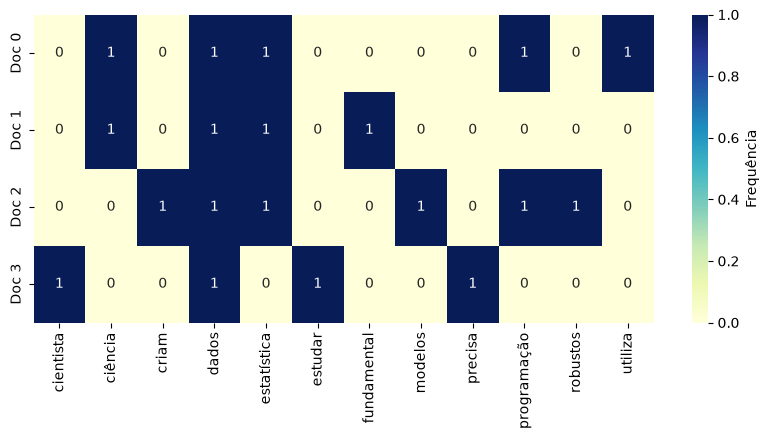

In [47]:
# Apresentar um heatmap

plt.figure(figsize=(10,4))
sns.heatmap(
    X_freq.toarray(),
    cmap='YlGnBu',
    annot=True,
    fmt='d',
    cbar_kws={'label':'Frequência'},
    xticklabels=vocabulario,
    yticklabels=[f"Doc {i}" for i in range(len(corpus_tech))]
)


## N-Grams

In [51]:
def mostrar_ngrams(n_min,n_max,descricao):
    vec = CountVectorizer(ngram_range=(n_min,n_max), stop_words=list(stop_words_pt))
    X = vec.fit_transform(corpus_tech)
    vocab = vec.get_feature_names_out()

    print(f"{descricao}: {len(vocab)} ngrams")
    print(vocab[:10])

    return vec, X,vocab


In [52]:
# Bigrams
vec_bigram, X_bigram, vocab_bigram = mostrar_ngrams(2,2,"Bigram")

Bigram: 14 ngrams
['cientista dados' 'ciência dados' 'criam modelos' 'dados precisa'
 'dados robustos' 'dados utiliza' 'estatística criam'
 'estatística fundamental' 'estatística programação' 'fundamental ciência']


In [53]:
df_bigram = pd.DataFrame(X_bigram.toarray(), columns=vocab_bigram)
df_bigram.head()

,cientista dados,ciência dados,criam modelos,dados precisa,dados robustos,dados utiliza,estatística criam,estatística fundamental,estatística programação,fundamental ciência,modelos dados,precisa estudar,programação estatística,utiliza estatística
0,0,1,0,0,0,1,0,0,1,0,0,0,0,1
1,0,1,0,0,0,0,0,1,0,1,0,0,0,0
2,0,0,1,0,1,0,1,0,0,0,1,0,1,0
3,1,0,0,1,0,0,0,0,0,0,0,1,0,0


In [50]:
# Trigrams
mostrar_ngrams(3,3,"Trigram")

Trigram: 11 ngrams
['cientista dados precisa' 'ciência dados utiliza' 'criam modelos dados'
 'dados precisa estudar' 'dados utiliza estatística'
 'estatística criam modelos' 'estatística fundamental ciência'
 'fundamental ciência dados' 'modelos dados robustos'
 'programação estatística criam']


## Análise de Colocações

In [55]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

In [56]:

corpus_tech = """
    A ciência de dados utiliza estatística e programação.
    A estatística é fundamental para a ciência de dados.
    Programação e estatística criam modelos de dados robustos.
    O cientista de dados precisa estudar muito.
    O mercado de ações é altamente volátil.
    Os carros autônomos são uma tendência da tecnologia e usam muita programação.
    A inteligência artificial usa muita matemática e estatística em sues algoritmos.
"""
    
tokens = nltk.word_tokenize(corpus_tech.lower(), language="portuguese")
tokens = [token for token in tokens if token.isalpha() and token not in stop_words_pt]
tokens

['ciência',
 'dados',
 'utiliza',
 'estatística',
 'programação',
 'estatística',
 'fundamental',
 'ciência',
 'dados',
 'programação',
 'estatística',
 'criam',
 'modelos',
 'dados',
 'robustos',
 'cientista',
 'dados',
 'precisa',
 'estudar',
 'mercado',
 'ações',
 'altamente',
 'volátil',
 'carros',
 'autônomos',
 'tendência',
 'tecnologia',
 'usam',
 'muita',
 'programação',
 'inteligência',
 'artificial',
 'usa',
 'muita',
 'matemática',
 'estatística',
 'sues',
 'algoritmos']

In [57]:
# Configurar o Finder de colocação do NLTK
bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(tokens)

# Filtrar pares que aparecem pelo menos 2 vezes
finder.apply_freq_filter(2)

In [58]:
# Top 5 por frequência
print(finder.nbest(bigram_measures.raw_freq,5))

[('ciência', 'dados'), ('programação', 'estatística')]


In [59]:
# Top 5 por PMI (Pointwise Mutual Information)
print(finder.nbest(bigram_measures.pmi,5))

[('ciência', 'dados'), ('programação', 'estatística')]
